## Bank Loan Analysis Project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Importing and observing data types

In [2]:
df = pd.read_excel('financial_loan.xlsx')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  object        
 2   application_type       38576 non-null  object        
 3   emp_length             38576 non-null  object        
 4   emp_title              37138 non-null  object        
 5   grade                  38576 non-null  object        
 6   home_ownership         38576 non-null  object        
 7   issue_date             38576 non-null  datetime64[ns]
 8   last_credit_pull_date  38576 non-null  datetime64[ns]
 9   last_payment_date      38576 non-null  datetime64[ns]
 10  loan_status            38576 non-null  object        
 11  next_payment_date      38576 non-null  datetime64[ns]
 12  member_id              38576 non-null  int64         
 13  p

## Creating a quick statistical preview

In [3]:
df.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007040,2021-06-08 13:36:34.193280512,2021-06-26 09:52:08.909166080,2021-07-26 20:42:20.605557760,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


## Starting analysis
### First task: Calculate the total number of loan applications. Additionally, calculate also the Month-to-Date (MTD) loan applications
### MTD means the loan at the latest period that the data provides

In [4]:
# Get the date from the issue_date column
issue_date = df['issue_date']
total_applications = issue_date.count()
print("Total loan applications: ", total_applications)

Total loan applications:  38576


In [5]:
# Now we calculate the MTD
start_date = issue_date.min()
latest_date = issue_date.max()
latest_date_year = latest_date.year
latest_date_month = latest_date.month
# Now we filter the data to get the MTD
mtd_data = df[(df['issue_date'].dt.year == latest_date_year) & (df['issue_date'].dt.month == latest_date_month)]
print("Total MTD: ", mtd_data.count())

Total MTD:  id                       4314
address_state            4314
application_type         4314
emp_length               4314
emp_title                4095
grade                    4314
home_ownership           4314
issue_date               4314
last_credit_pull_date    4314
last_payment_date        4314
loan_status              4314
next_payment_date        4314
member_id                4314
purpose                  4314
sub_grade                4314
term                     4314
verification_status      4314
annual_income            4314
dti                      4314
installment              4314
int_rate                 4314
loan_amount              4314
total_acc                4314
total_payment            4314
dtype: int64


## Second task: Calculate the total amount funded (all time and MTD)
### The total amount funded is the total amount that the bank paid for the applicants

In [6]:
# Since we are counting tw different time frames, we separate the dataset into full dan MTD
df_all_time = df
df_mtd = mtd_data

In [7]:
# Now we can start doing the aggregations
amount_funded_all_time = df_all_time['loan_amount'].sum()
print(f"Total amount funded all-time is: ${amount_funded_all_time:,.1f}")

amount_funded_mtd = df_mtd['loan_amount'].sum()
print(f"Total amount funded (MTD) is: ${amount_funded_mtd:,.1f}")

Total amount funded all-time is: $435,757,075.0
Total amount funded (MTD) is: $53,981,425.0


## Third task: Total amount received (all-time and MTD)
### Total amount received is total money that the applicants have paid plus the interest.

In [8]:
# We use the total_payment column
amount_received_all_time = df_all_time['total_payment'].sum()
# We can also divide the result with 1000000, to make it more readable
print(f"Total amount received all-time: ${amount_received_all_time/1000000:,.2f}M")

# Same thing with MTD
amount_received_mtd = df_mtd['total_payment'].sum()
print(f"Total amount received (MTD): ${amount_received_mtd/1000000:,.2f}")

Total amount received all-time: $473.07M
Total amount received (MTD): $58.07


## Fourth task: We find the average interest rate

In [9]:
# We calculate this all-time
avg_interest_rate = df_all_time['int_rate'].mean()
# Show it in %
print(f"Average interest rate: {avg_interest_rate*100:,.2f}%")

Average interest rate: 12.05%


# If we need all time statistics, we can actually get from the describe()
avg_interest_rate2 = df_all_time.describe()['int_rate']['mean']*100
print(f"Average interest rate: {avg_interest_rate2:,.2f}%")

## Fifth task: Calculate the Debt-to-Income (DTI) ratio
### It is used as parameter to observe the financial health of the applicants

In [10]:
# We count it all time as well
dti_ratio = df_all_time.describe()['dti']['mean']*100
print(f"Average DTI ratio: {dti_ratio:,.2f}")

Average DTI ratio: 13.33


## Now we split the data into Good Loans and Bad Loans.
### If the loan_status is Fully Paid or Current, they are good loans and Charged off are considered as Bad Loans

In [11]:
df_good_loans = df_all_time[df_all_time['loan_status'].isin(['Fully Paid', 'Current'])]
df_bad_loans = df_all_time[df_all_time['loan_status'].isin(['Charged Off'])]
good_loans_perc = (df_good_loans.count()["id"]/df_all_time.count()['id'])*100
bad_loans_perc = (df_bad_loans.count()["id"]/df_all_time.count()["id"])*100
print(f"Good loans: {good_loans_perc:.2f}% and Bad loans: {bad_loans_perc:.2f}%")

Good loans: 86.18% and Bad loans: 13.82%


## Now from here we can calculate the total money received and spent

In [12]:
# We can actually create function to calculate the amount received and spent
# As additional info, we can actually calculate the profit
def loanMetrics(df, cat):
    total_spent_in_mil = df['loan_amount'].sum()/1000000
    total_received_in_mil = df['total_payment'].sum()/1000000
    profit = total_received_in_mil - total_spent_in_mil
    print(
        f"Total spent ({cat}) loan: ${total_spent_in_mil:.2f}M\nTotal received ({cat}) loan: ${total_received_in_mil:.2f}M\nTotal profit ({cat}): ${profit:.2f}M"
    )
    return
good_loans_metric = loanMetrics(df_good_loans, 'good')
bad_loans_metric = loanMetrics(df_bad_loans, 'bad')
total_metric = loanMetrics(df_all_time, 'total')    

Total spent (good) loan: $370.22M
Total received (good) loan: $435.79M
Total profit (good): $65.56M
Total spent (bad) loan: $65.53M
Total received (bad) loan: $37.28M
Total profit (bad): $-28.25M
Total spent (total) loan: $435.76M
Total received (total) loan: $473.07M
Total profit (total): $37.31M


### I think we can see from the metrics that bad loans caused loss

## We dive into visualizations
### First task: Monthly trend issue. It is the total number of loans given monthly

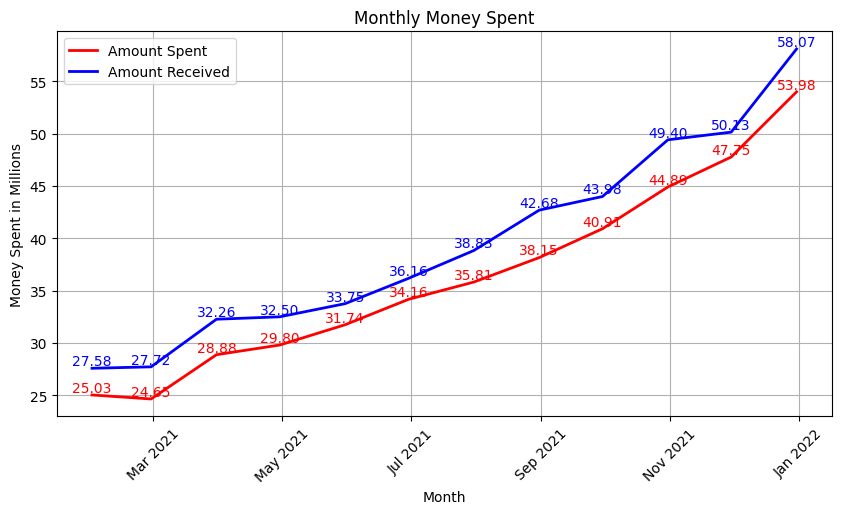

In [13]:
# We can use groupby() from the issue_date
# Since, we'll do running total for money spent and received, we can plot them together and even use function 
import matplotlib.dates as mdates
def plotRunningTotal(df):
    monthly_traffic = df.sort_values('issue_date').groupby(pd.Grouper(key='issue_date', freq='ME'))[['loan_amount', 'total_payment']].sum().div(1000000).reset_index()
    plt.figure(figsize=(10,5))
    plt.plot(
        monthly_traffic['issue_date'],
        monthly_traffic['loan_amount'],
        color='red',
        label='Amount Spent',
        linewidth=2
    )
    plt.plot(
        monthly_traffic['issue_date'],
        monthly_traffic['total_payment'],
        color='blue',
        label='Amount Received',
        linewidth=2
    )
    # Adding mark above line
    for i, row in monthly_traffic.iterrows():
        plt.text(
            row['issue_date'], row['loan_amount'], f"{row['loan_amount']:.2f}",
            ha='center', va='bottom', color='red'
        )
    for i, row in monthly_traffic.iterrows():
        plt.text(
            row['issue_date'], row['total_payment'], f"{row['total_payment']:.2f}",
            ha='center', va='bottom', color='blue'
        )
    plt.title('Monthly Money Spent')
    plt.xlabel('Month')
    plt.ylabel('Money Spent in Millions')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.show()


plotRunningTotal(df_all_time)



### We can see that the trend is going up except for January to February

## Before we dive into the regional analysis, we can observe the trends of loans monthly

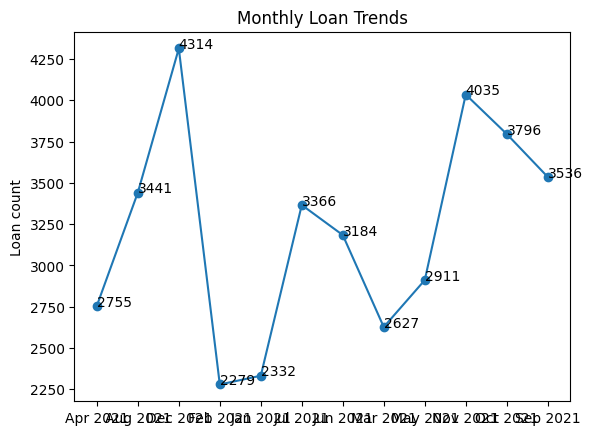

In [ ]:
trend_count = df_all_time.groupby(df_all_time['issue_date'].dt.strftime('%b %Y'))['id'].count().sort_index()

fig, ax = plt.subplots()

line = ax.plot(
    trend_count.index,
    trend_count.values,
    marker='o'
)
for x, y in zip(trend_count.index, trend_count.values):
    ax.text(x, y, str(y))
ax.set_title('Monthly Loan Trends')
ax.set_ylabel('Loan count')
plt.show()

In [36]:
trend_count.sort_values()

issue_date
Feb 2021    2279
Jan 2021    2332
Mar 2021    2627
Apr 2021    2755
May 2021    2911
Jun 2021    3184
Jul 2021    3366
Aug 2021    3441
Sep 2021    3536
Oct 2021    3796
Nov 2021    4035
Dec 2021    4314
Name: id, dtype: int64

### Next we are doing the regional analysis for observing region with most loan applications

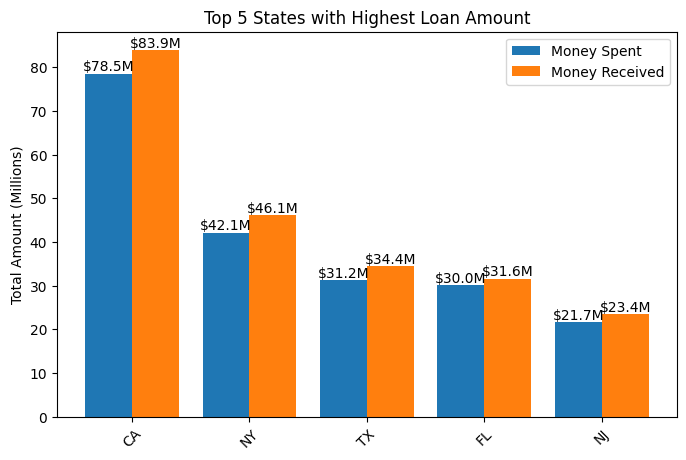

In [16]:
# First, we calculate the amount spent (loan_amount per state)
total_running_per_state = df_all_time.groupby('address_state')[['loan_amount', 'total_payment']].sum().div(1000000).reset_index()
top_5_state = total_running_per_state.sort_values(['loan_amount', 'total_payment'], ascending=False).head(5)
top_5_state = top_5_state.rename(
    columns={
        'address_state': 'State',
        'loan_amount': 'Money Spent',
        'total_payment': 'Money Received'
    }
)
top_5_state
# Then we plot using bar char for comparison
x = np.arange(len(top_5_state['State']))
width = 0.4
plt.figure(figsize=(8,5))
# Add label on the top of the bar
bars1 = plt.bar(x - width/2, top_5_state['Money Spent'], width, label='Money Spent')
bars2 = plt.bar(x + width/2, top_5_state['Money Received'], width, label='Money Received' )
plt.bar_label(bars1, fmt='$%.1fM')
plt.bar_label(bars2, fmt='$%.1fM')
plt.xticks(x, top_5_state['State'], rotation=45)
plt.legend()
plt.title('Top 5 States with Highest Loan Amount')
plt.ylabel('Total Amount (Millions)')
plt.show()


### We can actually go a bit further by comparing these top 5 states with the whole country and express the percentage using pie chart

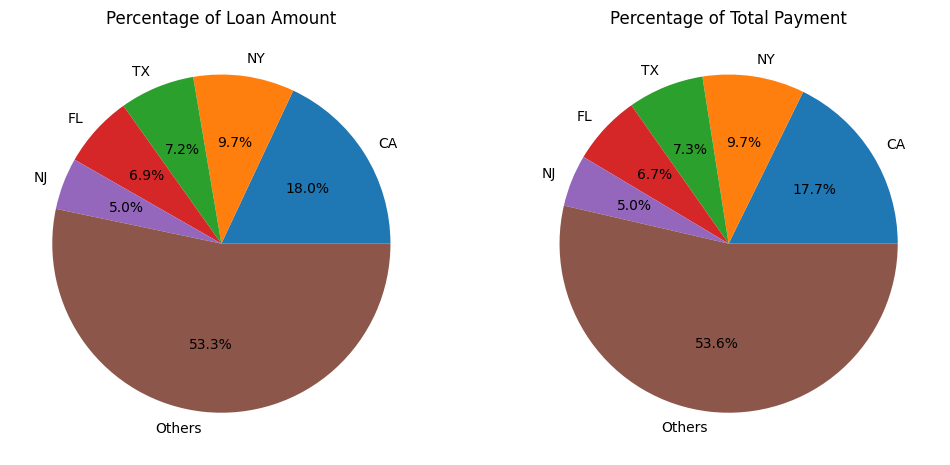

In [17]:
# First we observe for the money spent
states = top_5_state['State'].tolist()
values_spent = top_5_state['Money Spent'].tolist()
values_received = top_5_state['Money Received'].tolist()

others_spent = (
    total_running_per_state['loan_amount'].sum() - sum(values_spent)
)
others_received = (
    total_running_per_state['total_payment'].sum() - sum(values_received)
)
states.append('Others')
values_spent.append(others_spent)
values_received.append(others_received)

# Plot
fig, axes = plt.subplots(
    1,2,figsize=(12, 6)
)
axes[0].pie(
    values_spent,
    labels=states,
    autopct='%.1f%%'
)
axes[0].set_title('Percentage of Loan Amount')

axes[1].pie(
    values_received,
    labels=states,
    autopct='%.1f%%'
)
axes[1].set_title('Percentage of Total Payment')
plt.show()


### We can now observe the loan purpose

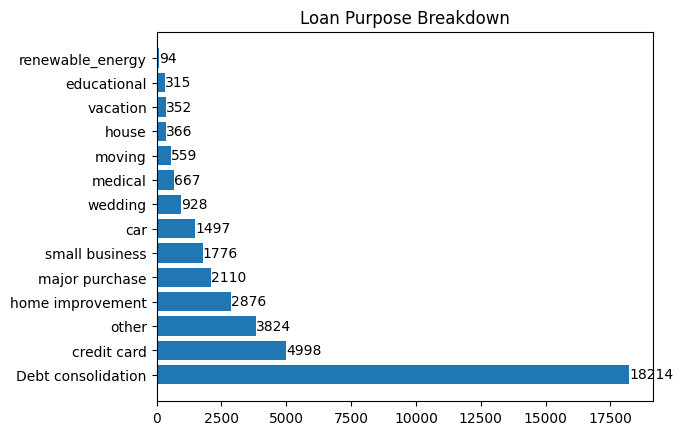

In [18]:
loan_purpose_count = df_all_time.groupby('purpose', sort=False).count()['id'].sort_values(ascending=False).reset_index(name='purpose_count')
loan_purpose_count

fig, ax = plt.subplots()
bars = ax.barh(
    loan_purpose_count['purpose'],
    loan_purpose_count['purpose_count']
)
ax.bar_label(bars, fmt='%.0f')
ax.set_title('Loan Purpose Breakdown')
plt.show()

### It is clearly seen from the chart that the reason people loan the money is to pay their debt

## Testing some tools for data cleaning

In [21]:
# Find percentage of missing value
missing = df.isnull().mean()*100
missing[missing>0].sort_values(ascending=False)

emp_title    3.727706
dtype: float64

In [24]:
# Find duplicate value - remember using df.duplicated() needs all columns with the exact same value to be duplicated
df_cp = df.copy()
df.duplicated().sum()

np.int64(0)

In [25]:
# Split between numerical and categorical column.
df.columns

Index(['id', 'address_state', 'application_type', 'emp_length', 'emp_title',
       'grade', 'home_ownership', 'issue_date', 'last_credit_pull_date',
       'last_payment_date', 'loan_status', 'next_payment_date', 'member_id',
       'purpose', 'sub_grade', 'term', 'verification_status', 'annual_income',
       'dti', 'installment', 'int_rate', 'loan_amount', 'total_acc',
       'total_payment'],
      dtype='object')

In [27]:
cat_cols = ['address_state', 'application_type', 'emp_title', 'grade']
# We fill the missing values for categorical column with 'Unknown'
df[cat_cols] = df[cat_cols].fillna('Unknown')
df.isnull().sum()

id                       0
address_state            0
application_type         0
emp_length               0
emp_title                0
grade                    0
home_ownership           0
issue_date               0
last_credit_pull_date    0
last_payment_date        0
loan_status              0
next_payment_date        0
member_id                0
purpose                  0
sub_grade                0
term                     0
verification_status      0
annual_income            0
dti                      0
installment              0
int_rate                 0
loan_amount              0
total_acc                0
total_payment            0
dtype: int64

In [28]:
# Look for unstandardize input (especially in text)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  object        
 2   application_type       38576 non-null  object        
 3   emp_length             38576 non-null  object        
 4   emp_title              38576 non-null  object        
 5   grade                  38576 non-null  object        
 6   home_ownership         38576 non-null  object        
 7   issue_date             38576 non-null  datetime64[ns]
 8   last_credit_pull_date  38576 non-null  datetime64[ns]
 9   last_payment_date      38576 non-null  datetime64[ns]
 10  loan_status            38576 non-null  object        
 11  next_payment_date      38576 non-null  datetime64[ns]
 12  member_id              38576 non-null  int64         
 13  p

In [32]:
df['emp_title'].nunique()

28526

In [33]:
df['issue_date']

0       2021-02-11
1       2021-01-01
2       2021-01-05
3       2021-02-25
4       2021-01-01
           ...    
38571   2021-07-11
38572   2021-10-11
38573   2021-09-11
38574   2021-10-11
38575   2021-07-11
Name: issue_date, Length: 38576, dtype: datetime64[ns]

In [35]:
df['issue_year'] = df['issue_date'].dt.year
df['issue_month'] = df['issue_date'].dt.month
df['issue_day'] = df['issue_date'].dt.day_name()
df['issue_day']

0        Thursday
1          Friday
2         Tuesday
3        Thursday
4          Friday
           ...   
38571      Sunday
38572      Monday
38573    Saturday
38574      Monday
38575      Sunday
Name: issue_day, Length: 38576, dtype: object